In [32]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("denvermagtibay/ai-generated-essays-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ai-generated-essays-dataset' dataset.
Path to dataset files: /kaggle/input/ai-generated-essays-dataset


In [33]:
import kagglehub
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path=kagglehub.dataset_download("denvermagtibay/ai-generated-essays-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ai-generated-essays-dataset' dataset.
Path to dataset files: /kaggle/input/ai-generated-essays-dataset


In [34]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

#download required nltks
nltk.download("punkt") #tokenizer
nltk.download("stopwords")    #stopwords
nltk.download("wordnet")    #wordnet for lemmatization
nltk.download("omw-1.4")    #lemmatization data
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [35]:
import os

#load dataset
df_directory_path = path # Use the 'path' variable from previous cells which holds the directory path

# List contents of the directory to find the CSV file
dataset_files = os.listdir(df_directory_path)
print(f"Files in the dataset directory: {dataset_files}")

# Assuming the main CSV file is named 'data.csv' or similar
# You might need to adjust this if the filename is different
try:
    csv_file_name = [f for f in dataset_files if f.endswith('.csv')][0]
    full_csv_path = os.path.join(df_directory_path, csv_file_name)
    df = pd.read_csv(full_csv_path)
    print("Dataset loaded successfully:")
    print(df.head())
except IndexError:
    print("No CSV file found in the downloaded dataset directory. Please check the directory contents.")
except Exception as e:
    print(f"An error occurred while loading the CSV file: {e}")



Files in the dataset directory: ['AI Generated Essays Dataset.csv']
Dataset loaded successfully:
                                                text  generated
0  Machine learning, a subset of artificial intel...          1
1  A decision tree, a prominent machine learning ...          1
2  Education, a cornerstone of societal progress,...          1
3  Computers, the backbone of modern technology, ...          1
4  Chess, a timeless game of strategy and intelle...          1


## 2. Convert Text to Lowercase

This step converts all text in the 'text' column to lowercase. This helps in standardizing the text, ensuring that words like 'The' and 'the' are treated as the same word during analysis.

In [36]:
# Convert all text to lowercase
df['text_lower'] = df['text'].apply(lambda x: x.lower() if isinstance(x, str) else x)

# Display the original and converted text for the first 5 rows
print("Original Text vs. Lowercased Text (first 5 rows):")
display(df[['text', 'text_lower']].head())

Original Text vs. Lowercased Text (first 5 rows):


,text,text_lower
0,"Machine learning, a subset of artificial intel...","machine learning, a subset of artificial intel..."
1,"A decision tree, a prominent machine learning ...","a decision tree, a prominent machine learning ..."
2,"Education, a cornerstone of societal progress,...","education, a cornerstone of societal progress,..."
3,"Computers, the backbone of modern technology, ...","computers, the backbone of modern technology, ..."
4,"Chess, a timeless game of strategy and intelle...","chess, a timeless game of strategy and intelle..."


## 3. Tokenization

Tokenization is the process of breaking down text into individual words or tokens. This is a fundamental step in NLP as most analyses are performed on these individual units.

In [37]:
from nltk.tokenize import word_tokenize

# Tokenize the lowercase text
df['tokens'] = df['text_lower'].apply(lambda x: word_tokenize(x) if isinstance(x, str) else [])

# Display tokens for the first 5 samples
print("Tokens for the first 5 samples:")
for i, tokens in enumerate(df['tokens'].head()):
    print(f"Sample {i+1}: {tokens}")

Tokens for the first 5 samples:
Sample 1: ['machine', 'learning', ',', 'a', 'subset', 'of', 'artificial', 'intelligence', ',', 'has', 'rapidly', 'emerged', 'as', 'a', 'transformative', 'force', ',', 'revolutionizing', 'industries', 'and', 'redefining', 'the', 'possibilities', 'of', 'technology', '.', 'at', 'its', 'core', ',', 'machine', 'learning', 'enables', 'computers', 'to', 'learn', 'from', 'data', 'and', 'make', 'informed', 'decisions', 'without', 'explicit', 'programming', ',', 'with', 'applications', 'ranging', 'from', 'image', 'recognition', 'and', 'language', 'processing', 'to', 'autonomous', 'systems', '.', 'as', 'machine', 'learning', 'continues', 'to', 'advance', ',', 'it', 'brings', 'both', 'opportunities', 'and', 'challenges', ',', 'with', 'issues', 'of', 'bias', ',', 'transparency', ',', 'and', 'privacy', 'demanding', 'careful', 'consideration', '.', 'the', 'impact', 'of', 'machine', 'learning', 'is', 'profound', ',', 'shaping', 'a', 'future', 'where', 'intelligent', 'sy

## 4. Stopword Removal

Stopwords are common words (like 'the', 'is', 'and') that often carry little meaning in text analysis. Removing them can help focus on more important words and reduce noise.

In [38]:
from nltk.corpus import stopwords

# Initialize English stopwords
stop_words = set(stopwords.words('english'))

# Function to remove stopwords
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

# Apply stopword removal
df['tokens_filtered'] = df['tokens'].apply(remove_stopwords)

# Display before and after stopword removal for the first 5 samples
print("Tokens Before and After Stopword Removal (first 5 samples):")
for i in range(5):
    print(f"\nSample {i+1}:")
    print(f"  Before: {df['tokens'].iloc[i]}")
    print(f"  After:  {df['tokens_filtered'].iloc[i]}")

Tokens Before and After Stopword Removal (first 5 samples):

Sample 1:
  Before: ['machine', 'learning', ',', 'a', 'subset', 'of', 'artificial', 'intelligence', ',', 'has', 'rapidly', 'emerged', 'as', 'a', 'transformative', 'force', ',', 'revolutionizing', 'industries', 'and', 'redefining', 'the', 'possibilities', 'of', 'technology', '.', 'at', 'its', 'core', ',', 'machine', 'learning', 'enables', 'computers', 'to', 'learn', 'from', 'data', 'and', 'make', 'informed', 'decisions', 'without', 'explicit', 'programming', ',', 'with', 'applications', 'ranging', 'from', 'image', 'recognition', 'and', 'language', 'processing', 'to', 'autonomous', 'systems', '.', 'as', 'machine', 'learning', 'continues', 'to', 'advance', ',', 'it', 'brings', 'both', 'opportunities', 'and', 'challenges', ',', 'with', 'issues', 'of', 'bias', ',', 'transparency', ',', 'and', 'privacy', 'demanding', 'careful', 'consideration', '.', 'the', 'impact', 'of', 'machine', 'learning', 'is', 'profound', ',', 'shaping', 'a'

## 5. Stemming

Stemming is a text normalization technique that reduces words to their root form (stem). While not always a valid word, the stem is useful for grouping related words together, which can be beneficial for analysis. Here, we'll apply the Porter Stemmer.

In [39]:
from nltk.stem import PorterStemmer

# Initialize Porter Stemmer
stemmer = PorterStemmer()

# Function to apply stemming to a list of tokens
def apply_stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

# Apply stemming to the filtered tokens
df['stemmed_tokens'] = df['tokens_filtered'].apply(apply_stemming)

# Display original tokens, filtered tokens, and stemmed tokens for at least 10 samples
print("Original Tokens, Filtered Tokens, and Stemmed Tokens (first 10 samples):")
for i in range(10):
    print(f"\nSample {i+1}:")
    print(f"  Original Tokens:  {df['tokens'].iloc[i]}")
    print(f"  Filtered Tokens:  {df['tokens_filtered'].iloc[i]}")
    print(f"  Stemmed Tokens:   {df['stemmed_tokens'].iloc[i]}")

Original Tokens, Filtered Tokens, and Stemmed Tokens (first 10 samples):

Sample 1:
  Original Tokens:  ['machine', 'learning', ',', 'a', 'subset', 'of', 'artificial', 'intelligence', ',', 'has', 'rapidly', 'emerged', 'as', 'a', 'transformative', 'force', ',', 'revolutionizing', 'industries', 'and', 'redefining', 'the', 'possibilities', 'of', 'technology', '.', 'at', 'its', 'core', ',', 'machine', 'learning', 'enables', 'computers', 'to', 'learn', 'from', 'data', 'and', 'make', 'informed', 'decisions', 'without', 'explicit', 'programming', ',', 'with', 'applications', 'ranging', 'from', 'image', 'recognition', 'and', 'language', 'processing', 'to', 'autonomous', 'systems', '.', 'as', 'machine', 'learning', 'continues', 'to', 'advance', ',', 'it', 'brings', 'both', 'opportunities', 'and', 'challenges', ',', 'with', 'issues', 'of', 'bias', ',', 'transparency', ',', 'and', 'privacy', 'demanding', 'careful', 'consideration', '.', 'the', 'impact', 'of', 'machine', 'learning', 'is', 'profoun

## 6. Lemmatization and Comparison with Stemming

Lemmatization is a more sophisticated process than stemming. It reduces words to their base or dictionary form (lemma), which is always a valid word. This provides a more accurate representation of the word's meaning. We'll compare the results of lemmatization (which was done earlier and stored in `df['lemmatized_text']`) with the stemming results.

Note: The `lemmatized_text` column was generated by applying lemmatization to the original 'text' column directly, not to the `tokens_filtered`. For a direct comparison, we'll re-apply lemmatization to the `tokens_filtered` or use the existing `df['lemmatized_text']` column by tokenizing it for comparison with stemmed tokens.

In [40]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Initialize WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# Function to apply lemmatization to a list of tokens
def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# Apply lemmatization to the filtered tokens
df['lemmatized_tokens'] = df['tokens_filtered'].apply(apply_lemmatization)

# Display filtered, stemmed, and lemmatized tokens for 10 samples for comparison
print("Filtered Tokens, Stemmed Tokens, and Lemmatized Tokens (first 10 samples for comparison):")
for i in range(10):
    print(f"\nSample {i+1}:")
    print(f"  Filtered:   {df['tokens_filtered'].iloc[i]}")
    print(f"  Stemmed:    {df['stemmed_tokens'].iloc[i]}")
    print(f"  Lemmatized: {df['lemmatized_tokens'].iloc[i]}")

Filtered Tokens, Stemmed Tokens, and Lemmatized Tokens (first 10 samples for comparison):

Sample 1:
  Filtered:   ['machine', 'learning', ',', 'subset', 'artificial', 'intelligence', ',', 'rapidly', 'emerged', 'transformative', 'force', ',', 'revolutionizing', 'industries', 'redefining', 'possibilities', 'technology', '.', 'core', ',', 'machine', 'learning', 'enables', 'computers', 'learn', 'data', 'make', 'informed', 'decisions', 'without', 'explicit', 'programming', ',', 'applications', 'ranging', 'image', 'recognition', 'language', 'processing', 'autonomous', 'systems', '.', 'machine', 'learning', 'continues', 'advance', ',', 'brings', 'opportunities', 'challenges', ',', 'issues', 'bias', ',', 'transparency', ',', 'privacy', 'demanding', 'careful', 'consideration', '.', 'impact', 'machine', 'learning', 'profound', ',', 'shaping', 'future', 'intelligent', 'systems', 'contribute', 'efficiency', ',', 'innovation', ',', 'interconnected', 'world', '.']
  Stemmed:    ['machin', 'learn', 

## 7. Bag of Words (BoW) Implementation

Bag of Words (BoW) is a technique that represents text as a collection of word counts, disregarding word order. Each document is represented as a vector where each dimension corresponds to a unique word in the vocabulary, and the value is the frequency of that word in the document.

In [41]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Join the filtered tokens back into strings for CountVectorizer
df['processed_text'] = df['tokens_filtered'].apply(lambda x: ' '.join(x))

# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the processed text data
bow_matrix = vectorizer.fit_transform(df['processed_text'])

# Display vocabulary
print("\nVocabulary (first 20 words):", list(vectorizer.vocabulary_.keys())[:20])

# Display feature names (all unique words in the vocabulary)
print("\nFeature Names (first 20 words):", vectorizer.get_feature_names_out()[:20])

# Convert the BoW matrix to a DataFrame for better readability
bow_df_display = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Display the BoW matrix (first 5 rows, first 10 columns for brevity)
print("\nBag of Words Matrix (first 5 rows, first 10 columns):")
print(bow_df_display.iloc[:5, :10])

# Display the shape of the BoW matrix
print("\nShape of BoW Matrix:", bow_matrix.shape)



Vocabulary (first 20 words): ['machine', 'learning', 'subset', 'artificial', 'intelligence', 'rapidly', 'emerged', 'transformative', 'force', 'revolutionizing', 'industries', 'redefining', 'possibilities', 'technology', 'core', 'enables', 'computers', 'learn', 'data', 'make']

Feature Names (first 20 words): ['00' '000' '00000001' '0000euro124' '001' '006' '00am' '00pm' '10' '100'
 '1000' '1000s' '100500' '100assume' '100x' '1011' '1012' '1015' '1019'
 '1020']

Bag of Words Matrix (first 5 rows, first 10 columns):
   00  000  00000001  0000euro124  001  006  00am  00pm  10  100
0   0    0         0            0    0    0     0     0   0    0
1   0    0         0            0    0    0     0     0   0    0
2   0    0         0            0    0    0     0     0   0    0
3   0    0         0            0    0    0     0     0   0    0
4   0    0         0            0    0    0     0     0   0    0

Shape of BoW Matrix: (1460, 17557)


## 8. TF-IDF Vectorization

TF-IDF (Term Frequency-Inverse Document Frequency) is a numerical statistic that reflects how important a word is to a document in a collection or corpus. It is often used as a weighting factor in information retrieval and text mining. The TF-IDF value increases proportionally to the number of times a word appears in the document but is offset by the frequency of the word in the corpus, which helps to adjust for the fact that some words appear more frequently in general.

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
# Using the 'processed_text' column which contains the lowercased, tokenized, and stopword-removed text
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the processed text data
tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed_text'])

# Display vocabulary (first 20 words)
print("\nVocabulary (first 20 words):", list(tfidf_vectorizer.vocabulary_.keys())[:20])

# Display feature names (all unique words in the vocabulary)
print("\nFeature Names (first 20 words):", tfidf_vectorizer.get_feature_names_out()[:20])

# Convert the TF-IDF matrix to a DataFrame for better readability
tfidf_df_display = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Display the TF-IDF matrix (first 5 rows, first 10 columns for brevity)
print("\nTF-IDF Matrix (first 5 rows, first 10 columns):")
print(tfidf_df_display.iloc[:5, :10])

# Display the shape of the TF-IDF matrix
print("\nShape of TF-IDF Matrix:", tfidf_matrix.shape)



Vocabulary (first 20 words): ['machine', 'learning', 'subset', 'artificial', 'intelligence', 'rapidly', 'emerged', 'transformative', 'force', 'revolutionizing', 'industries', 'redefining', 'possibilities', 'technology', 'core', 'enables', 'computers', 'learn', 'data', 'make']

Feature Names (first 20 words): ['00' '000' '00000001' '0000euro124' '001' '006' '00am' '00pm' '10' '100'
 '1000' '1000s' '100500' '100assume' '100x' '1011' '1012' '1015' '1019'
 '1020']

TF-IDF Matrix (first 5 rows, first 10 columns):
    00  000  00000001  0000euro124  001  006  00am  00pm   10  100
0  0.0  0.0       0.0          0.0  0.0  0.0   0.0   0.0  0.0  0.0
1  0.0  0.0       0.0          0.0  0.0  0.0   0.0   0.0  0.0  0.0
2  0.0  0.0       0.0          0.0  0.0  0.0   0.0   0.0  0.0  0.0
3  0.0  0.0       0.0          0.0  0.0  0.0   0.0   0.0  0.0  0.0
4  0.0  0.0       0.0          0.0  0.0  0.0   0.0   0.0  0.0  0.0

Shape of TF-IDF Matrix: (1460, 17557)


## 9. Word Cloud from Preprocessed Text

Previously, a Word Cloud was generated from the original text. This time, we'll generate it from the preprocessed text (`processed_text` column, which has been lowercased, tokenized, and had stopwords removed) to visualize the most prominent words after cleaning.

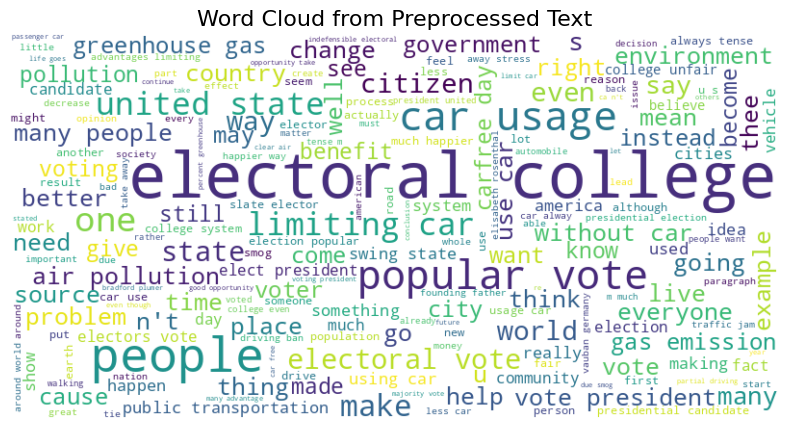

In [44]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join the preprocessed text into a single string for the Word Cloud
preprocessed_text_for_cloud = " ".join(df['processed_text'].dropna())

# Generate Word Cloud
wordcloud_preprocessed = WordCloud(width=800, height=400, background_color='white').generate(preprocessed_text_for_cloud)

# Display the Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_preprocessed, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud from Preprocessed Text", fontsize=16)
plt.show()